**Project Title:**

**Customer Segmentation using K-Means Clustering**

In today’s competitive market, businesses need to understand their customers to deliver
personalized experiences and increase revenue. However, customers differ in terms of age,
income, purchasing habits, and loyalty, making it difficult to target them effectively.
This project aims to analyze customer purchasing behavior using features such as age, annual
income, purchase amount, purchase frequency, region, and loyalty score. The objective is to
group customers into meaningful segments based on their similarities.

By performing customer segmentation, businesses can:

- Identify high-value and low-value customers

-  Design targeted marketing strategies

- Improve customer retention and loyalty

- Optimize product recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hanaksoy/customer-purchasing-behaviors")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-purchasing-behaviors' dataset.
Path to dataset files: /kaggle/input/customer-purchasing-behaviors


In [4]:
import os

print("Path:", path)
print("Files:", os.listdir(path))

Path: /kaggle/input/customer-purchasing-behaviors
Files: ['Customer Purchasing Behaviors.csv']


In [5]:
import pandas as pd
import os

# Automatically pick CSV file
file_name = [f for f in os.listdir(path) if f.endswith(".csv")][0]
file_path = os.path.join(path, file_name)

print("Using file:", file_path)

df = pd.read_csv(file_path)
df.head()

Using file: /kaggle/input/customer-purchasing-behaviors/Customer Purchasing Behaviors.csv


,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13


In [6]:
for root, dirs, files in os.walk(path):
    print(root, files)

/kaggle/input/customer-purchasing-behaviors ['Customer Purchasing Behaviors.csv']


In [7]:
import pandas as pd

file_path = "/kaggle/input/customer-purchasing-behaviors/Customer Purchasing Behaviors.csv"

df = pd.read_csv(file_path)
df.head()

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13


In [8]:
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (238, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             238 non-null    int64  
 1   age                 238 non-null    int64  
 2   annual_income       238 non-null    int64  
 3   purchase_amount     238 non-null    int64  
 4   loyalty_score       238 non-null    float64
 5   region              238 non-null    object 
 6   purchase_frequency  238 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 13.1+ KB
None

Missing Values:
user_id               0
age                   0
annual_income         0
purchase_amount       0
loyalty_score         0
region                0
purchase_frequency    0
dtype: int64


In [9]:
df = df.drop_duplicates()

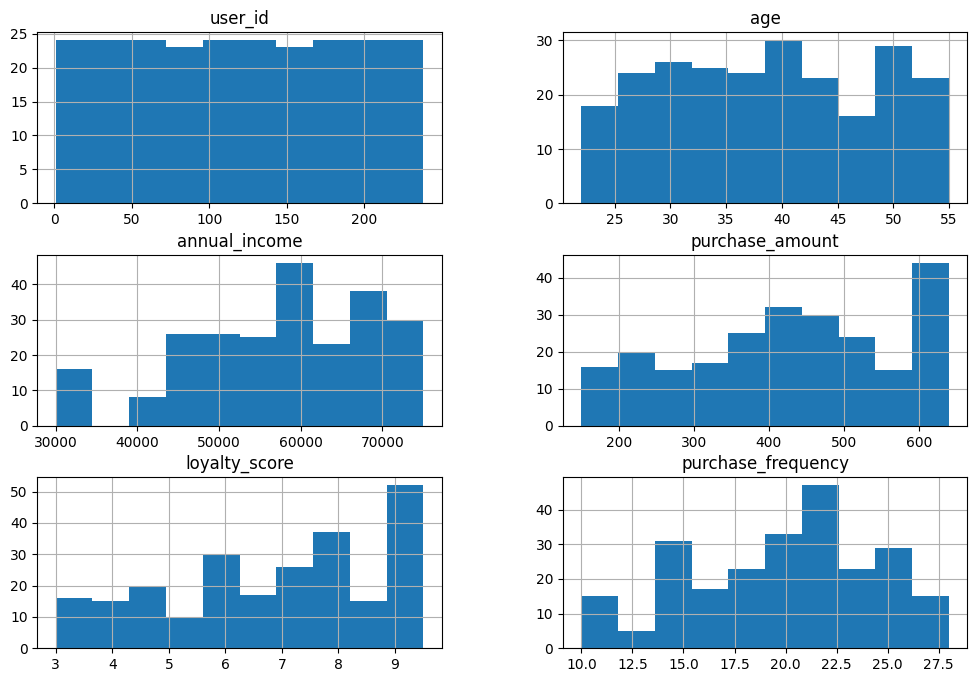

In [10]:
df.hist(figsize=(12,8))
plt.show()

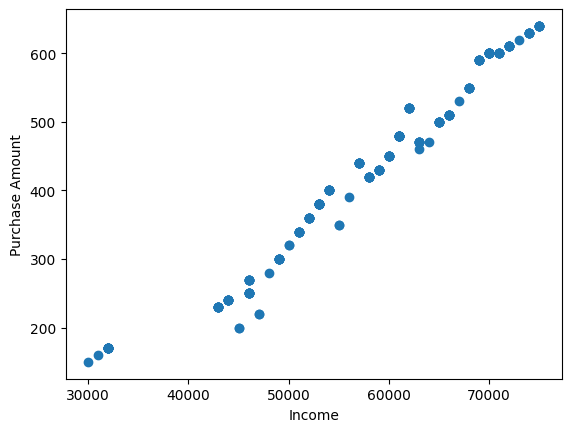

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.scatter(df['annual_income'], df['purchase_amount'])
plt.xlabel("Income")
plt.ylabel("Purchase Amount")
plt.show()

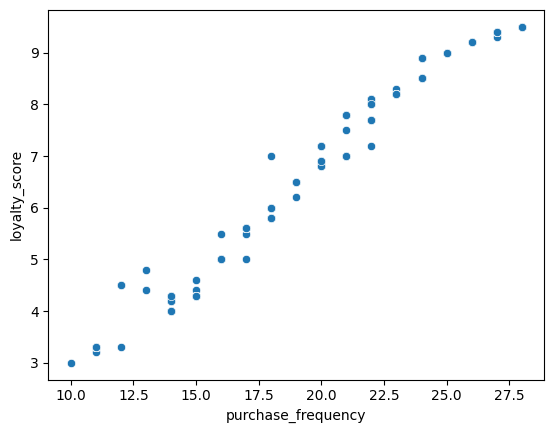

In [12]:
sns.scatterplot(x='purchase_frequency', y='loyalty_score', data=df)
plt.show()

In [13]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [14]:
features = df[['annual_income', 'purchase_amount',
               'purchase_frequency', 'loyalty_score']]

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

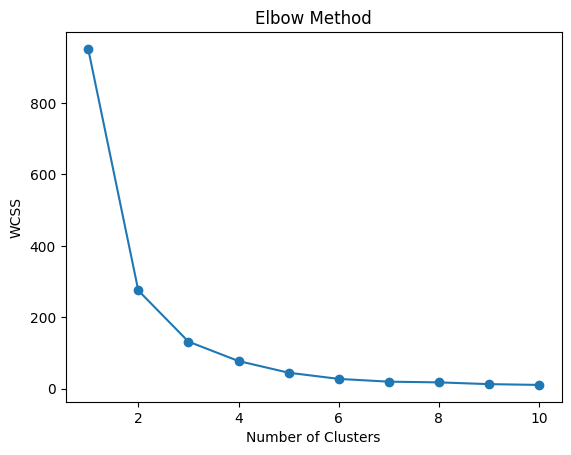

In [16]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [17]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters

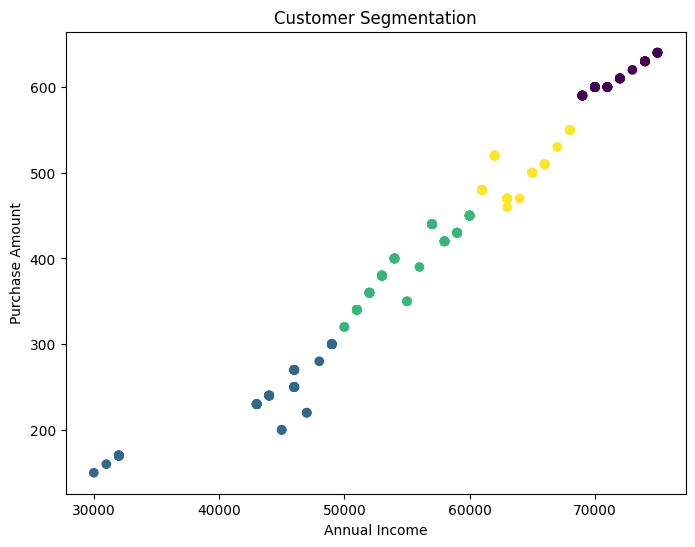

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(df['annual_income'], df['purchase_amount'],
            c=df['Cluster'], cmap='viridis')

plt.xlabel("Annual Income")
plt.ylabel("Purchase Amount")
plt.title("Customer Segmentation")

plt.show()

In [19]:
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)

            user_id        age  annual_income  purchase_amount  loyalty_score  \
Cluster                                                                         
0        126.115385  51.557692   71557.692308       609.807692       9.142308   
1        111.610169  26.779661   41915.254237       230.338983       4.091525   
2        121.438356  35.342466   55136.986301       396.986301       6.415068   
3        119.129630  43.777778   63777.777778       500.370370       7.998148   

         purchase_frequency  region_North  region_South  region_West  
Cluster                                                               
0                 25.711538      0.134615      0.173077     0.692308  
1                 13.508475      0.627119      0.254237     0.067797  
2                 18.958904      0.315068      0.342466     0.315068  
3                 22.111111      0.203704      0.518519     0.259259  
